# The linear algebra of Bessel functions -- eigenvalues, modes, and Mie scattering
### a differential operator becomes a matrix; its eigenvalues are the Bessel zeros

> *"You can only measure change."* -- Bahram Jalali

That is exactly the structure here. Bessel's equation is an **eigenvalue problem**:
the radial operator $L=-\tfrac{d^2}{dr^2}-\tfrac1r\tfrac{d}{dr}+\tfrac{n^2}{r^2}$,
discretized, is a **matrix** whose eigenvalues are the squared Bessel zeros
$(\alpha_m/R)^2$ and whose eigenvectors *are* the Bessel functions $J_n$. And the
three-term **recurrence** $J_{n-1}+J_{n+1}=\tfrac{2n+1}{x}J_n$ -- a relation between
*neighbors*, i.e. a difference -- is what actually builds the spherical Bessel
functions in your SEALS/Mie code. Linear algebra + a difference relation. Civilian
education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import bessel_linalg as bl
print("ready")

ready


## 1. Bessel's equation IS an eigenvalue problem

Build the operator matrix for $n=0$ and diagonalize it. The eigenvalues, square-
rooted, are the Bessel zeros -- including the famous $\alpha_1=2.4048$, the
fundamental of a circular drum. No special-function library: just `eig`.

In [2]:
for n, ref in [(0, [2.4048,5.5201,8.6537]), (1, [3.8317,7.0156]), (2, [5.1356,8.4172])]:
    z = bl.bessel_zeros(n, k=len(ref))
    print(f"  J_{n} zeros from matrix eigenvalues: {np.round(z,4)}   (known {ref})")
print("\na differential operator -> a matrix -> its eigenvalues are the Bessel zeros")

  J_0 zeros from matrix eigenvalues: [2.4048 5.5201 8.6537]   (known [2.4048, 5.5201, 8.6537])


  J_1 zeros from matrix eigenvalues: [3.8317 7.0156]   (known [3.8317, 7.0156])


  J_2 zeros from matrix eigenvalues: [5.1356 8.4172]   (known [5.1356, 8.4172])

a differential operator -> a matrix -> its eigenvalues are the Bessel zeros


## 2. The eigenvectors are the Bessel functions (a vibrating drum)

The $n=0$ eigenvectors are the radial vibration modes of a circular drumhead: each
is $J_0(\alpha_m r/R)$, with $m{-}1$ interior nodes, and its eigenvalue sets the
mode's frequency. The matrix *found* these shapes -- we never typed a Bessel
function.

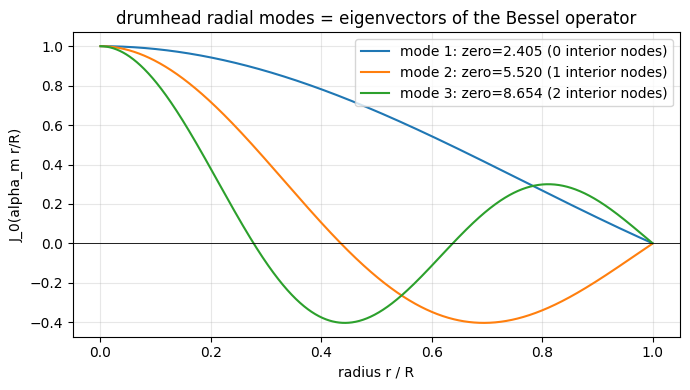

In [3]:
r, zeros, modes = bl.bessel_modes(0, k=3)
plt.figure(figsize=(7,4))
for m in range(3):
    plt.plot(r, modes[m], label=f"mode {m+1}: zero={zeros[m]:.3f} ({m} interior nodes)")
plt.axhline(0, color="k", lw=0.6); plt.xlabel("radius r / R"); plt.ylabel("J_0(alpha_m r/R)")
plt.title("drumhead radial modes = eigenvectors of the Bessel operator"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Orthogonality -> the Fourier-Bessel series

Because the $J_0(\alpha_m r/R)$ are **orthogonal** (with weight $r$), any radial
profile expands in them -- the same projection-by-inner-product idea as a Fourier
series, but on the drum's natural basis. Here we expand $f(r)=1-r^2$ and rebuild it.

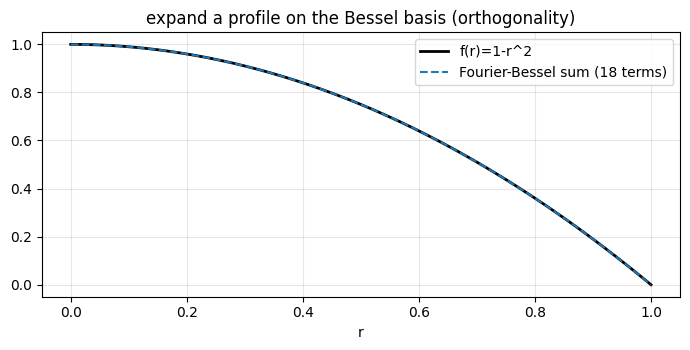

max reconstruction error (interior): 0.0002


In [4]:
r = np.linspace(1e-4, 1.0, 1500); f = 1 - r**2
zeros = bl.bessel_zeros(0, k=18)
c = bl.fourier_bessel_coeffs(f, r, zeros)
recon = bl.fourier_bessel_reconstruct(c, r, zeros)
plt.figure(figsize=(7,3.6))
plt.plot(r, f, "k", lw=2, label="f(r)=1-r^2")
plt.plot(r, recon, "--", label="Fourier-Bessel sum (18 terms)")
plt.xlabel("r"); plt.legend(); plt.title("expand a profile on the Bessel basis (orthogonality)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("max reconstruction error (interior):", np.max(np.abs(recon-f)[50:-50]).round(4))

## 4. Spherical Bessel functions -> Mie scattering (the SEALS tie)

In 3D (a sphere) the radial functions are the **spherical** Bessel functions
$j_n(x)$, built by the recurrence $j_{n+1}=\tfrac{2n+1}{x}j_n-j_{n-1}$ from
$j_0=\sin x/x$. These are exactly the functions in the Mie coefficients
$a_n,b_n$ in `projects/seals/seals_stable.py` -- the scattering pattern SEALS
encodes is a sum over these spherical-Bessel partial waves.

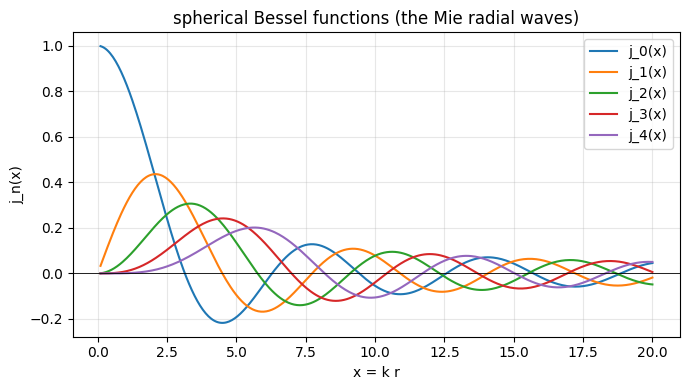

recurrence j_{n-1}+j_{n+1} = (2n+1)/x j_n holds: True


In [5]:
xs = np.linspace(0.1, 20, 400)
plt.figure(figsize=(7,4))
for n in range(5):
    plt.plot(xs, [bl.spherical_jn(n, x)[n] for x in xs], label=f"j_{n}(x)")
plt.axhline(0, color="k", lw=0.6); plt.xlabel("x = k r"); plt.ylabel("j_n(x)")
plt.title("spherical Bessel functions (the Mie radial waves)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# the recurrence is a difference relation between neighbors -- 'you can only measure change'
x = 7.0; j = bl.spherical_jn(6, x)
print("recurrence j_{n-1}+j_{n+1} = (2n+1)/x j_n holds:",
      np.allclose([j[n-1]+j[n+1] for n in range(1,6)], [(2*n+1)/x*j[n] for n in range(1,6)]))

## Takeaway

1. **Bessel's equation is an eigenvalue problem.** Discretize the radial operator and
   its eigenvalues are the zeros $\alpha_m$ (incl. the drum's 2.4048), its
   eigenvectors the functions $J_n$ -- pure numerical linear algebra.
2. The eigenfunctions are an **orthogonal basis** -> the Fourier-Bessel series, the
   drum's analogue of Fourier.
3. In 3D the **spherical** Bessel functions, built by a three-term **recurrence**,
   are the Mie radial waves your SEALS code sums over.

The recurrence is a relation between *neighbors* -- a difference. *You can only
measure change*: the modes, the zeros, and the scattering all come out of operators
that compare a quantity to its neighbors. Civilian education.